In [1]:
import numpy as np
import h5py as h5
import pycorr
from astropy.io import fits 
import os 


import requests
from pathlib import Path

In [2]:
path = 'https://data.desi.lbl.gov/public/dr1/survey/catalogs/dr1/mocks/AbacusSummit/dark/v4.2/altmtl0/mock0/LSScats/LRG_NGC_clustering.dat.fits' #LRG_NGC_0_clustering

ran_path = 'https://data.desi.lbl.gov/public/dr1/survey/catalogs/dr1/mocks/AbacusSummit/dark/v4.2/altmtl0/mock0/rancomb_0darkwdupspec_zdone.fits'

In [3]:
with fits.open(path) as file:
    file.info()

    data_shape = file[1].data.shape
    print(f"Data dimensions (shape): {data_shape}")

    # 2. Get size in bytes of the uncompressed data array in memory
    data_bytes = file[1].data.nbytes
    print(f"Array memory size: {data_bytes / (1024**2):.2f} MB")

    

Filename: /home/cosweeney/.astropy/cache/download/url/3dd5cbe51365862373de3dbd0ff94288/contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   ()      
  1  LSS           1 BinTableHDU     45   1487585R x 15C   [K, E, E, E, K, 1A, D, D, D, D, D, D, D, D, D]   
Data dimensions (shape): (1487585,)
Array memory size: 143.29 MB


In [8]:
with fits.open(ran_path) as file:
    file.info()

    data_shape = file[1].data.shape
    print(f"Data dimensions (shape): {data_shape}")

    # 2. Get size in bytes of the uncompressed data array in memory
    data_bytes = file[1].data.nbytes
    print(f"Array memory size: {data_bytes / (1024**2):.2f} MB")

Filename: /home/cosweeney/.astropy/cache/download/url/fc46393dbf27ef951c028592bb58b861/contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  LSS           1 BinTableHDU     40   47648406R x 12C   [K, K, K, D, D, K, J, E, E, E, E, E]   
Data dimensions (shape): (47648406,)
Array memory size: 3271.76 MB


In [ ]:
# download data needed to measure multipoles for one mock, LRG NGC mock 0


BASE = ('https://data.desi.lbl.gov/public/dr1/survey/catalogs/dr1/mocks/'
        'AbacusSummit/dark/v4.2/altmtl0/mock0/LSScats')
DEST = Path('/spiffball/cosweeney/mocks/AbacusSummit/dark/altmtl0/')
CAPS = ['NGC']

def fetch(url, dest):
    if dest.exists():
        print(f'skip {dest.name} ({dest.stat().st_size / 1e9:.2f} GB)')
        return
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        tmp = dest.with_suffix(dest.suffix + '.part')
        with open(tmp, 'wb') as f:
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk)
        tmp.rename(dest)
    print(f'got  {dest.name} ({dest.stat().st_size / 1e9:.2f} GB)')

DEST.mkdir(parents=True, exist_ok=True)
for cap in CAPS:
    names = [f'LRG_{cap}_clustering.dat.fits']
    names += [f'LRG_{cap}_{n}_clustering.ran.fits' for n in range(18)]
    for name in names:
        fetch(f'{BASE}/{name}', DEST / name)

skip LRG_NGC_clustering.dat.fits (0.15 GB)
skip LRG_NGC_0_clustering.ran.fits (1.11 GB)
skip LRG_NGC_1_clustering.ran.fits (1.11 GB)
skip LRG_NGC_2_clustering.ran.fits (1.11 GB)
skip LRG_NGC_3_clustering.ran.fits (1.11 GB)
skip LRG_NGC_4_clustering.ran.fits (1.11 GB)
skip LRG_NGC_5_clustering.ran.fits (1.11 GB)
skip LRG_NGC_6_clustering.ran.fits (1.11 GB)
skip LRG_NGC_7_clustering.ran.fits (1.11 GB)
got  LRG_NGC_8_clustering.ran.fits (1.11 GB)
got  LRG_NGC_9_clustering.ran.fits (1.11 GB)
got  LRG_NGC_10_clustering.ran.fits (1.11 GB)
got  LRG_NGC_11_clustering.ran.fits (1.11 GB)
got  LRG_NGC_12_clustering.ran.fits (1.11 GB)
got  LRG_NGC_13_clustering.ran.fits (1.11 GB)
got  LRG_NGC_14_clustering.ran.fits (1.11 GB)
got  LRG_NGC_15_clustering.ran.fits (1.11 GB)
got  LRG_NGC_16_clustering.ran.fits (1.11 GB)
got  LRG_NGC_17_clustering.ran.fits (1.11 GB)


In [8]:
BASE = ('https://data.desi.lbl.gov/public/dr1/survey/catalogs/dr1/mocks/' # now LRG SGC for mock 0
        'AbacusSummit/dark/v4.2/altmtl0/mock0/LSScats')
DEST = Path('/spiffball/cosweeney/mocks/AbacusSummit/dark/altmtl0')

def fetch(url, dest):
    if dest.exists():
        print(f'skip {dest.name} ({dest.stat().st_size / 1e9:.2f} GB)')
        return
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        tmp = dest.with_suffix(dest.suffix + '.part')
        with open(tmp, 'wb') as f:
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk)
        tmp.rename(dest)
    print(f'got  {dest.name} ({dest.stat().st_size / 1e9:.2f} GB)')

DEST.mkdir(parents=True, exist_ok=True)
names = ['LRG_SGC_clustering.dat.fits']
names += [f'LRG_SGC_{n}_clustering.ran.fits' for n in range(4)]
for name in names:
    fetch(f'{BASE}/{name}', DEST / name)

got  LRG_SGC_clustering.dat.fits (0.07 GB)
got  LRG_SGC_0_clustering.ran.fits (0.58 GB)
got  LRG_SGC_1_clustering.ran.fits (0.58 GB)
got  LRG_SGC_2_clustering.ran.fits (0.58 GB)
got  LRG_SGC_3_clustering.ran.fits (0.58 GB)


In [25]:
# try computing xi(s, mu) for single mock

path = '/spiffball/cosweeney/mocks/AbacusSummit/dark/altmtl0'+'/LRG_NGC_clustering.dat.fits'
rpath = '/spiffball/cosweeney/mocks/AbacusSummit/dark/altmtl0'+'/LRG_NGC_0_clustering.ran.fits'


hdul = fits.open(path)

header = hdul[1].header
data = hdul[1].data

In [24]:
data.names

['TARGETID',
 'RA',
 'DEC',
 'Z',
 'NTILE',
 'PHOTSYS',
 'FRAC_TLOBS_TILES',
 'WEIGHT',
 'WEIGHT_ZFAIL',
 'WEIGHT_COMP',
 'WEIGHT_SYS',
 'NX',
 'WEIGHT_FKP',
 'WEIGHT_SN',
 'WEIGHT_IMLIN']

In [ ]:
from pycorr import TwoPointCorrelationFunction, TwoPointEstimator, NaturalTwoPointEstimator, utils, setup_logging


edges = (np.linspace(20., 130., 30), np.linspace(-1., 1., 201))
result = TwoPointCorrelationFunction('smu', edges, data_positions1=data_positions1, data_weights1=data_weights1,
                                     randoms_positions1=randoms_positions1, randoms_weights1=randoms_weights1,
                                     engine='corrfunc', nthreads=4)

In [6]:
import os
import fitsio

from pycorr import TwoPointCorrelationFunction, TwoPointEstimator, NaturalTwoPointEstimator, utils, setup_logging
from cosmoprimo.fiducial import DESI

ZMIN, ZMAX = 0.8, 1.1          # LRG3; change per bin
NRAN = 4
NTHREADS = 84 #os.cpu_count()


NGC_path = '/spiffball/cosweeney/mocks/AbacusSummit/dark/altmtl0'+'/LRG_NGC_clustering.dat.fits'
NGC_rpath = '/spiffball/cosweeney/mocks/AbacusSummit/dark/altmtl0'+'/LRG_NGC_0_clustering.ran.fits'

SGC_path = '/spiffball/cosweeney/mocks/AbacusSummit/dark/altmtl0'+'/LRG_SGC_clustering.dat.fits'
SGC_rpath = '/spiffball/cosweeney/mocks/AbacusSummit/dark/altmtl0'+'/LRG_SGC_0_clustering.ran.fits'

setup_logging()
cosmo = DESI(engine='camb')

COLS = ['RA', 'DEC', 'Z', 'WEIGHT', 'WEIGHT_FKP']

def load(name):
    cat = fitsio.read(name, columns=COLS)
    cat = cat[(cat['Z'] > ZMIN) & (cat['Z'] < ZMAX)]
    positions = np.array([cat['RA'], cat['DEC'], cosmo.comoving_radial_distance(cat['Z'])])
    return positions, cat['WEIGHT'] * cat['WEIGHT_FKP']

def concat(cats):
    positions = [np.concatenate([c[0][i] for c in cats]) for i in range(3)]
    weights = np.concatenate([c[1] for c in cats])
    return positions, weights

NGC_pos, NGC_w = load(NGC_path)
NGC_randoms = [load(f'/spiffball/cosweeney/mocks/AbacusSummit/dark/altmtl0/LRG_NGC_{n}_clustering.ran.fits') for n in range(NRAN)]
NGC_randoms_pos, NGC_randoms_w = concat(NGC_randoms)


SGC_pos, SGC_w = load(SGC_path)
SGC_randoms = [load(f'/spiffball/cosweeney/mocks/AbacusSummit/dark/altmtl0/LRG_SGC_{n}_clustering.ran.fits') for n in range(NRAN)]
SGC_randoms_pos, SGC_randoms_w = concat(SGC_randoms)


edges = (np.linspace(20., 130., 30), np.linspace(-1., 1., 201))


result = TwoPointCorrelationFunction( # NGC
    'smu', edges,
    data_positions1=NGC_pos, data_weights1=NGC_w,
    randoms_positions1=NGC_randoms_pos, randoms_weights1=NGC_randoms_w,
    position_type='rdd', estimator='landyszalay', nthreads=NTHREADS,
) + TwoPointCorrelationFunction( # SGC
    'smu', edges,
    data_positions1=SGC_pos, data_weights1=SGC_w,
    randoms_positions1=SGC_randoms_pos, randoms_weights1=SGC_randoms_w,
    position_type='rdd', estimator='landyszalay', nthreads=NTHREADS,
)

# result.save(DEST / f'xi_smu_LRG_NGC_z{ZMIN}-{ZMAX}.npy')

[000034.36]  08-17 10:17  TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.LandySzalayTwoPointEstimator'>.
[000034.36]  08-17 10:17  TwoPointCorrelationFunction  INFO     Running auto-correlation.
[000034.36]  08-17 10:17  TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.
[000035.09]  08-17 10:18  TwoPointCorrelationFunction  INFO     Computing two-point counts D1R2.
[000061.70]  08-17 10:18  TwoPointCorrelationFunction  INFO     Computing two-point counts R1R2.
[000259.78]  08-17 10:21  TwoPointCorrelationFunction  INFO     Correlation function computed in elapsed time 225.42 s.
[000259.78]  08-17 10:21  TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.LandySzalayTwoPointEstimator'>.
[000259.79]  08-17 10:21  TwoPointCorrelationFunction  INFO     Running auto-correlation.
[000259.79]  08-17 10:21  TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.
[000260.04]  08-17 1

In [7]:
s, poles = result(ells=(0, 2, 4), return_sep=True)

xi_smu = result.corr           # shape (50, 200), the s-mu grid
s_edges, mu_edges = result.edges

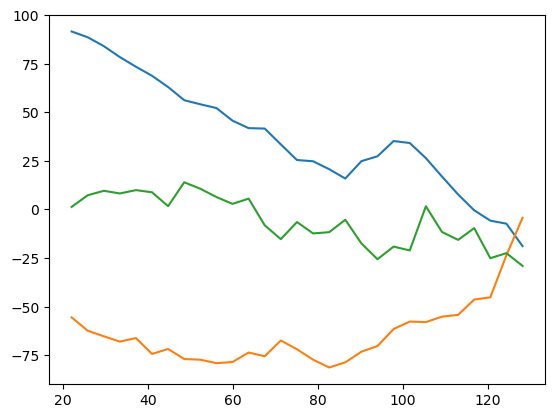

In [8]:
import matplotlib.pyplot as plt 

for i in range(len(poles)):
    plt.plot(s, s**2*poles[i])

In [ ]:
# TODO: download 24 other mocks and 4 randoms for each (works out to be at most?) ~ 894 Gb

(0.15 * 12 + 1.1*4*25)*2 *  4


894.4000000000001

In [9]:
LOCAL_ROOT = Path('/spiffball/cosweeney/mocks/AbacusSummit/dark')
REMOTE_ROOT = ('https://data.desi.lbl.gov/public/dr1/survey/catalogs/dr1/mocks/'
               'AbacusSummit/dark/v4.2')

def names_for(cap, nran=4):
    return ([f'LRG_{cap}_clustering.dat.fits']
            + [f'LRG_{cap}_{n}_clustering.ran.fits' for n in range(nran)])

for i in range(1, 25):
    base = f'{REMOTE_ROOT}/altmtl{i}/mock{i}/LSScats'
    dest = LOCAL_ROOT / f'altmtl{i}'
    dest.mkdir(parents=True, exist_ok=True)
    for cap in ('NGC', 'SGC'):
        for name in names_for(cap):
            try:
                fetch(f'{base}/{name}', dest / name)
            except Exception as e:
                print(f'FAILED {i} {name}: {e}')

FAILED 1 LRG_NGC_clustering.dat.fits: name 'fetch' is not defined
FAILED 1 LRG_NGC_0_clustering.ran.fits: name 'fetch' is not defined
FAILED 1 LRG_NGC_1_clustering.ran.fits: name 'fetch' is not defined
FAILED 1 LRG_NGC_2_clustering.ran.fits: name 'fetch' is not defined
FAILED 1 LRG_NGC_3_clustering.ran.fits: name 'fetch' is not defined
FAILED 1 LRG_SGC_clustering.dat.fits: name 'fetch' is not defined
FAILED 1 LRG_SGC_0_clustering.ran.fits: name 'fetch' is not defined
FAILED 1 LRG_SGC_1_clustering.ran.fits: name 'fetch' is not defined
FAILED 1 LRG_SGC_2_clustering.ran.fits: name 'fetch' is not defined
FAILED 1 LRG_SGC_3_clustering.ran.fits: name 'fetch' is not defined
FAILED 2 LRG_NGC_clustering.dat.fits: name 'fetch' is not defined
FAILED 2 LRG_NGC_0_clustering.ran.fits: name 'fetch' is not defined
FAILED 2 LRG_NGC_1_clustering.ran.fits: name 'fetch' is not defined
FAILED 2 LRG_NGC_2_clustering.ran.fits: name 'fetch' is not defined
FAILED 2 LRG_NGC_3_clustering.ran.fits: name 'fetch' i

In [5]:
test_path = '/spiffball/salcedo/AbacusSummit/Snapshots/base_c130/base_c130_ph000/z0p500/halo_base_c130_ph000_z0p500.h5'

with h5.File(test_path, 'r') as hdf:
    print(hdf['halos'].dtype.names) 

('mass', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'r100', 'r90', 'r67', 'r33', 'r10', 'vrms', 'gid')


In [3]:
# check space needed for all mocks data (minus covariance matrices)
ROOT = 'https://data.desi.lbl.gov/public/dr1/survey/catalogs/dr1/mocks/AbacusSummit'
NRAN, NMOCK = 4, 25

TRACERS = {
    'BGS_BRIGHT':    ('bright', 'v1'),
    'LRG':           ('dark', 'v4.2'),
    'ELG_LOPnotqso': ('dark', 'v4.2'),
    'QSO':           ('dark', 'v4.2'),
}

def probe(tracer, prog, version, imock=0):
    base = f'{ROOT}/{prog}/{version}/altmtl{imock}/mock{imock}/LSScats'
    total, missing = 0, []
    for cap in ('NGC', 'SGC'):
        names = [f'{tracer}_{cap}_clustering.dat.fits']
        names += [f'{tracer}_{cap}_{n}_clustering.ran.fits' for n in range(NRAN)]
        for name in names:
            r = requests.head(f'{base}/{name}', allow_redirects=True)
            size = int(r.headers.get('content-length', 0))
            if r.status_code != 200 or size == 0:
                missing.append(name)
            total += size
    return total, missing

grand = 0
for tracer, (prog, version) in TRACERS.items():
    per_mock, missing = probe(tracer, prog, version)
    subtotal = per_mock * NMOCK
    grand += subtotal
    print(f'{tracer:16s} {per_mock/1e9:7.2f} GB/mock  ->  {subtotal/1e12:6.2f} TB')
    for m in missing:
        print(f'    MISSING: {m}')

print(f'\nTOTAL for {NMOCK} realizations: {grand/1e12:.2f} TB')

BGS_BRIGHT          8.20 GB/mock  ->    0.21 TB
LRG                 6.99 GB/mock  ->    0.17 TB
ELG_LOPnotqso       6.74 GB/mock  ->    0.17 TB
QSO                 7.98 GB/mock  ->    0.20 TB

TOTAL for 25 realizations: 0.75 TB


In [6]:
import shutil
free = shutil.disk_usage('/spiffball/cosweeney').free
print(f'free: {free/1e12:.2f} TB')

free: 6.03 TB


In [7]:
# let's download 'em

LOCAL_ROOT = Path('/spiffball/cosweeney/mocks/AbacusSummit')

def names_for(tracer, cap):
    return ([f'{tracer}_{cap}_clustering.dat.fits']
            + [f'{tracer}_{cap}_{n}_clustering.ran.fits' for n in range(NRAN)])

def fetch(url, dest):
    if dest.exists():
        print(f'skip {dest.name} ({dest.stat().st_size / 1e9:.2f} GB)')
        return
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        tmp = dest.with_suffix(dest.suffix + '.part')
        with open(tmp, 'wb') as f:
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk)
        tmp.rename(dest)
    print(f'got  {dest.name} ({dest.stat().st_size / 1e9:.2f} GB)')

failures = []
for tracer, (prog, version) in TRACERS.items():
    for i in range(NMOCK):
        base = f'{ROOT}/{prog}/{version}/altmtl{i}/mock{i}/LSScats'
        dest = LOCAL_ROOT / prog / f'altmtl{i}'
        dest.mkdir(parents=True, exist_ok=True)
        for cap in ('NGC', 'SGC'):
            for name in names_for(tracer, cap):
                try:
                    fetch(f'{base}/{name}', dest / name)
                except Exception as e:
                    failures.append((f'{base}/{name}', dest / name, repr(e)))
                    print(f'FAILED {tracer} mock{i} {name}: {e}')

print(f'\ndone, {len(failures)} failures')

skip BGS_BRIGHT_NGC_clustering.dat.fits (0.25 GB)
skip BGS_BRIGHT_NGC_0_clustering.ran.fits (1.39 GB)
skip BGS_BRIGHT_NGC_1_clustering.ran.fits (1.39 GB)
skip BGS_BRIGHT_NGC_2_clustering.ran.fits (1.39 GB)
skip BGS_BRIGHT_NGC_3_clustering.ran.fits (1.39 GB)
skip BGS_BRIGHT_SGC_clustering.dat.fits (0.09 GB)
skip BGS_BRIGHT_SGC_0_clustering.ran.fits (0.57 GB)
skip BGS_BRIGHT_SGC_1_clustering.ran.fits (0.57 GB)
skip BGS_BRIGHT_SGC_2_clustering.ran.fits (0.57 GB)
skip BGS_BRIGHT_SGC_3_clustering.ran.fits (0.57 GB)
skip BGS_BRIGHT_NGC_clustering.dat.fits (0.25 GB)
skip BGS_BRIGHT_NGC_0_clustering.ran.fits (1.39 GB)
skip BGS_BRIGHT_NGC_1_clustering.ran.fits (1.39 GB)
skip BGS_BRIGHT_NGC_2_clustering.ran.fits (1.39 GB)
skip BGS_BRIGHT_NGC_3_clustering.ran.fits (1.39 GB)
skip BGS_BRIGHT_SGC_clustering.dat.fits (0.09 GB)
skip BGS_BRIGHT_SGC_0_clustering.ran.fits (0.57 GB)
skip BGS_BRIGHT_SGC_1_clustering.ran.fits (0.57 GB)
skip BGS_BRIGHT_SGC_2_clustering.ran.fits (0.57 GB)
skip BGS_BRIGHT_SGC_

In [5]:
ROOT = 'https://data.desi.lbl.gov/public/dr1/survey/catalogs/dr1/mocks/AbacusSummit'
LOCAL_ROOT = Path('/spiffball/cosweeney/mocks/AbacusSummit')

NRAN, NMOCK = 4, 25

TRACERS = {
    'BGS_BRIGHT':    ('bright', 'v1'),
    'LRG':           ('dark', 'v4.2'),
    'ELG_LOPnotqso': ('dark', 'v4.2'),
    'QSO':           ('dark', 'v4.2'),
}

for tracer, (prog, version) in TRACERS.items():
    found = len(list((LOCAL_ROOT / prog).glob(f'altmtl*/{tracer}_*_clustering.*.fits')))
    print(f'{tracer:16s} {found} / {NMOCK * 2 * (NRAN + 1)}')

BGS_BRIGHT       250 / 250
LRG              263 / 250
ELG_LOPnotqso    250 / 250
QSO              250 / 250


In [6]:
# fucked up the BGS downloads
ROOT = 'https://data.desi.lbl.gov/public/dr1/survey/catalogs/dr1/mocks/AbacusSummit'
LOCAL_ROOT = Path('/spiffball/cosweeney/mocks/AbacusSummit')

NRAN, NMOCK = 4, 25

TRACERS = {
    'BGS_BRIGHT':    ('bright', 'v1'),
    'LRG':           ('dark', 'v4.2'),
    'ELG_LOPnotqso': ('dark', 'v4.2'),
    'QSO':           ('dark', 'v4.2'),
}

def names_for(tracer, cap):
    return ([f'{tracer}_{cap}_clustering.dat.fits']
            + [f'{tracer}_{cap}_{n}_clustering.ran.fits' for n in range(NRAN)])

def fetch(url, dest):
    if dest.exists():
        print(f'skip {dest.name} ({dest.stat().st_size / 1e9:.2f} GB)')
        return
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        tmp = dest.with_suffix(dest.suffix + '.part')
        with open(tmp, 'wb') as f:
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk)
        tmp.rename(dest)
    print(f'got  {dest.name} ({dest.stat().st_size / 1e9:.2f} GB)')


TRACERS['BGS_BRIGHT-21.5'] = ('bright', 'v1')
del TRACERS['BGS_BRIGHT']

TRACER = 'BGS_BRIGHT-21.5'
prog, version = TRACERS[TRACER]

failures = []
for i in range(NMOCK):
    base = f'{ROOT}/{prog}/{version}/altmtl{i}/mock{i}/LSScats'
    dest = LOCAL_ROOT / prog / f'altmtl{i}'
    dest.mkdir(parents=True, exist_ok=True)
    for cap in ('NGC', 'SGC'):
        for name in names_for(TRACER, cap):
            try:
                fetch(f'{base}/{name}', dest / name)
            except Exception as e:
                failures.append(name)
                print(f'FAILED mock{i} {name}: {e}')

print(f'{len(failures)} failures')

skip BGS_BRIGHT-21.5_NGC_clustering.dat.fits (0.04 GB)
skip BGS_BRIGHT-21.5_NGC_0_clustering.ran.fits (1.50 GB)
skip BGS_BRIGHT-21.5_NGC_1_clustering.ran.fits (1.50 GB)
skip BGS_BRIGHT-21.5_NGC_2_clustering.ran.fits (1.50 GB)
skip BGS_BRIGHT-21.5_NGC_3_clustering.ran.fits (1.50 GB)
skip BGS_BRIGHT-21.5_SGC_clustering.dat.fits (0.01 GB)
skip BGS_BRIGHT-21.5_SGC_0_clustering.ran.fits (0.62 GB)
skip BGS_BRIGHT-21.5_SGC_1_clustering.ran.fits (0.62 GB)
skip BGS_BRIGHT-21.5_SGC_2_clustering.ran.fits (0.62 GB)
skip BGS_BRIGHT-21.5_SGC_3_clustering.ran.fits (0.62 GB)
skip BGS_BRIGHT-21.5_NGC_clustering.dat.fits (0.04 GB)
skip BGS_BRIGHT-21.5_NGC_0_clustering.ran.fits (1.50 GB)
skip BGS_BRIGHT-21.5_NGC_1_clustering.ran.fits (1.50 GB)
skip BGS_BRIGHT-21.5_NGC_2_clustering.ran.fits (1.50 GB)
skip BGS_BRIGHT-21.5_NGC_3_clustering.ran.fits (1.50 GB)
skip BGS_BRIGHT-21.5_SGC_clustering.dat.fits (0.01 GB)
skip BGS_BRIGHT-21.5_SGC_0_clustering.ran.fits (0.62 GB)
skip BGS_BRIGHT-21.5_SGC_1_clustering.r

In [4]:
old = sorted((LOCAL_ROOT / 'bright').glob('altmtl*/BGS_BRIGHT_*.fits'))
print(f'{len(old)} files, {sum(p.stat().st_size for p in old) / 1e9:.1f} GB')
for p in old:
    print(p)

250 files, 205.0 GB
/spiffball/cosweeney/mocks/AbacusSummit/bright/altmtl0/BGS_BRIGHT_NGC_0_clustering.ran.fits
/spiffball/cosweeney/mocks/AbacusSummit/bright/altmtl0/BGS_BRIGHT_NGC_1_clustering.ran.fits
/spiffball/cosweeney/mocks/AbacusSummit/bright/altmtl0/BGS_BRIGHT_NGC_2_clustering.ran.fits
/spiffball/cosweeney/mocks/AbacusSummit/bright/altmtl0/BGS_BRIGHT_NGC_3_clustering.ran.fits
/spiffball/cosweeney/mocks/AbacusSummit/bright/altmtl0/BGS_BRIGHT_NGC_clustering.dat.fits
/spiffball/cosweeney/mocks/AbacusSummit/bright/altmtl0/BGS_BRIGHT_SGC_0_clustering.ran.fits
/spiffball/cosweeney/mocks/AbacusSummit/bright/altmtl0/BGS_BRIGHT_SGC_1_clustering.ran.fits
/spiffball/cosweeney/mocks/AbacusSummit/bright/altmtl0/BGS_BRIGHT_SGC_2_clustering.ran.fits
/spiffball/cosweeney/mocks/AbacusSummit/bright/altmtl0/BGS_BRIGHT_SGC_3_clustering.ran.fits
/spiffball/cosweeney/mocks/AbacusSummit/bright/altmtl0/BGS_BRIGHT_SGC_clustering.dat.fits
/spiffball/cosweeney/mocks/AbacusSummit/bright/altmtl1/BGS_BRIGH

In [7]:
new = sorted((LOCAL_ROOT / 'bright').glob('altmtl*/BGS_BRIGHT-21.5_*.fits'))
print(f'{len(new)} files, {sum(p.stat().st_size for p in new) / 1e9:.1f} GB')

250 files, 212.7 GB


In [8]:
assert not (set(old) & set(new))

In [9]:
for p in old:
    p.unlink()

In [11]:
d0 = LOCAL_ROOT / 'bright' / 'altmtl0'
T = 'BGS_BRIGHT-21.5'

for cap in ('NGC', 'SGC'):
    ndat = fits.getheader(d0 / f'{T}_{cap}_clustering.dat.fits', 1)['NAXIS2']
    nran = fits.getheader(d0 / f'{T}_{cap}_0_clustering.ran.fits', 1)['NAXIS2']
    print(f'{cap}: data {ndat:>9,}  ran/file {nran:>10,}  ratio {nran / ndat:5.1f}')

NGC: data   364,102  ran/file 13,258,404  ratio  36.4
SGC: data   133,897  ran/file  5,448,639  ratio  40.7


In [15]:
import fitsio

from pycorr import TwoPointCorrelationFunction, TwoPointEstimator, NaturalTwoPointEstimator, utils, setup_logging
from cosmoprimo.fiducial import DESI

setup_logging()
cosmo = DESI(engine='camb')

ZBINS = {
    'BGS_BRIGHT':    [(0.1, 0.4)],
    'LRG':           [(0.4, 0.6), (0.6, 0.8), (0.8, 1.1)],
    'ELG_LOPnotqso': [(0.8, 1.1), (1.1, 1.6)],
    'QSO':           [(0.8, 2.1)],
}

def survey_check(tracer, prog, zmin, zmax, nran=NRAN, imock=0):
    d = LOCAL_ROOT / prog / f'altmtl{imock}'
    nd = nr = 0
    for cap in ('NGC', 'SGC'):
        dat = fitsio.read(d / f'{tracer}_{cap}_clustering.dat.fits', columns=['Z'])
        ran = fitsio.read(d / f'{tracer}_{cap}_0_clustering.ran.fits', columns=['Z'])
        nd += ((dat['Z'] > zmin) & (dat['Z'] < zmax)).sum()
        nr += ((ran['Z'] > zmin) & (ran['Z'] < zmax)).sum()

    r = cosmo.comoving_radial_distance(np.array([zmin, zmax]))
    vol = 4 * np.pi / 3 * (r[1]**3 - r[0]**3) * (AREA_DEG2 / 41253.)
    nbar_r = nr * nran / vol
    return nd, nr, nr / nd, nbar_r, nbar_r**2 * vol

AREA_DEG2 = 7500.   # ~DR1 dark footprint; BGS differs, adjust if you rerun it

print(f'{"tracer":16s} {"zbin":12s} {"data":>9s} {"ran/f":>11s} {"ratio":>6s} '
      f'{"n_ran":>8s} {"rel cost":>9s}')
for tracer, (prog, _) in TRACERS.items():
    for zmin, zmax in ZBINS[tracer]:
        nd, nr, ratio, nbar_r, cost = survey_check(tracer, prog, zmin, zmax)
        print(f'{tracer:16s} {f"{zmin}-{zmax}":12s} {nd:>9,} {nr:>11,} '
              f'{ratio:>6.1f} {nbar_r:>8.1e} {cost:>9.2e}')

tracer           zbin              data       ran/f  ratio    n_ran  rel cost
LRG              0.4-0.6        518,526   3,481,432    6.7  7.8e-03  1.08e+05
LRG              0.6-0.8        774,246   5,192,781    6.7  7.5e-03  1.55e+05
LRG              0.8-1.1        862,220   5,787,485    6.7  4.0e-03  9.35e+04
ELG_LOPnotqso    0.8-1.1        993,374   6,172,083    6.2  4.3e-03  1.06e+05
ELG_LOPnotqso    1.1-1.6      1,419,357   8,770,141    6.2  2.8e-03  9.93e+04
QSO              0.8-2.1        857,545  18,124,736   21.1  2.2e-03  1.63e+05


KeyError: 'BGS_BRIGHT-21.5'

[000000.12]  08-23 00:00  TwoPointEstimator            INFO     Loading /spiffball/cosweeney/mocks/AbacusSummit/bright/altmtl0/BGS_BRIGHT-21.5_GCcomb_z0.1-0.4_xismu.npy.
[000000.13]  08-23 00:00  TwoPointEstimator            INFO     Loading /spiffball/cosweeney/mocks/AbacusSummit/bright/altmtl1/BGS_BRIGHT-21.5_GCcomb_z0.1-0.4_xismu.npy.
[000000.14]  08-23 00:00  TwoPointEstimator            INFO     Loading /spiffball/cosweeney/mocks/AbacusSummit/bright/altmtl2/BGS_BRIGHT-21.5_GCcomb_z0.1-0.4_xismu.npy.
[000000.15]  08-23 00:00  TwoPointEstimator            INFO     Loading /spiffball/cosweeney/mocks/AbacusSummit/bright/altmtl3/BGS_BRIGHT-21.5_GCcomb_z0.1-0.4_xismu.npy.
[000000.16]  08-23 00:00  TwoPointEstimator            INFO     Loading /spiffball/cosweeney/mocks/AbacusSummit/bright/altmtl4/BGS_BRIGHT-21.5_GCcomb_z0.1-0.4_xismu.npy.
[000000.18]  08-23 00:00  TwoPointEstimator            INFO     Loading /spiffball/cosweeney/mocks/AbacusSummit/bright/altmtl5/BGS_BRIGHT-21.5_GCcomb_

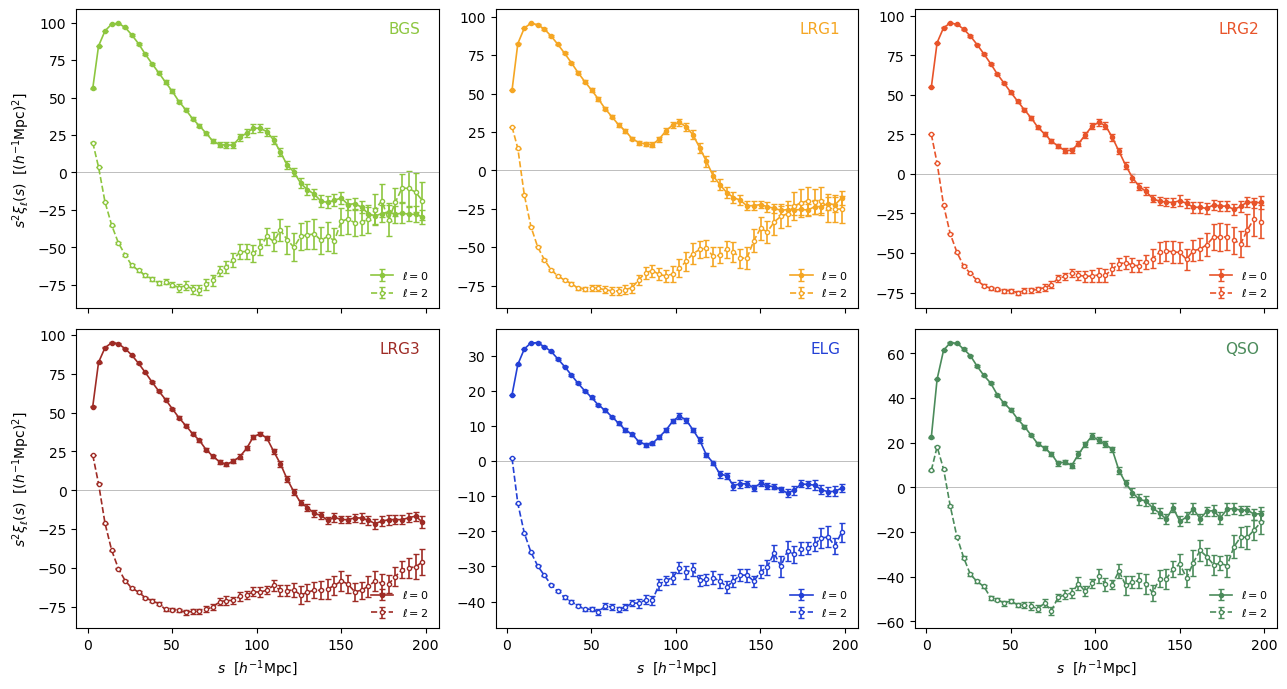

In [8]:
import matplotlib.pyplot as plt

ROOT = 'https://data.desi.lbl.gov/public/dr1/survey/catalogs/dr1/mocks/AbacusSummit'
LOCAL_ROOT = Path('/spiffball/cosweeney/mocks/AbacusSummit')

import fitsio

from pycorr import TwoPointCorrelationFunction, TwoPointEstimator, NaturalTwoPointEstimator, utils, setup_logging
from cosmoprimo.fiducial import DESI

setup_logging()
cosmo = DESI(engine='camb')

NRAN, NMOCK = 4, 25

# tracer key, program, z-bin, colour (eyedropped from the DESI DR1 figure)
SAMPLES = {
    'BGS':  ('BGS_BRIGHT-21.5', 'bright', (0.1, 0.4), '#8DC63F'),
    'LRG1': ('LRG',             'dark',   (0.4, 0.6), '#F5A623'),
    'LRG2': ('LRG',             'dark',   (0.6, 0.8), '#E8542A'),
    'LRG3': ('LRG',             'dark',   (0.8, 1.1), '#9E2B25'),
    'ELG':  ('ELG_LOPnotqso',   'dark',   (1.1, 1.6), '#2340D6'),
    'QSO':  ('QSO',             'dark',   (0.8, 2.1), '#4B8B5B'),
}

# SREBIN, SRANGE = 4, (20., 150.)

def load_poles(tracer, prog, zmin, zmax):
    """Return s and array of shape (nmock, 2, nbins) for ells 0, 2."""
    s, out = None, []
    for i in range(NMOCK):
        p = (LOCAL_ROOT / prog / f'altmtl{i}' /
             f'{tracer}_GCcomb_z{zmin}-{zmax}_xismu.npy')
        if not p.exists():
            continue
        r = TwoPointCorrelationFunction.load(p)[::SREBIN]#.select(SRANGE)
        s, poles = r(ells=(0, 2), return_sep=True)
        out.append(poles)
    return s, np.array(out)

def jackknife(x):
    """Delete-one jackknife mean and error over axis 0."""
    n = len(x)
    means = np.array([np.delete(x, i, axis=0).mean(axis=0) for i in range(n)])
    mean = x.mean(axis=0)
    err = np.sqrt((n - 1) / n * ((means - mean)**2).sum(axis=0))
    return mean, err

SREBIN = 4   # SRANGE no longer used — full 0-200 range kept

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True)

for ax, (label, (tracer, prog, (zmin, zmax), colour)) in zip(axes.ravel(), SAMPLES.items()):
    s, poles = load_poles(tracer, prog, zmin, zmax)
    if not len(poles):
        ax.text(0.5, 0.5, f'{label}', ha='center', va='center',
                transform=ax.transAxes, color='0.5')
        continue
    mean, err = jackknife(poles)
    ax.errorbar(s, s**2 * mean[0], s**2 * err[0], color=colour,
                marker='o', ms=3, lw=1.2, capsize=2, label=r'$\ell=0$')
    ax.errorbar(s, s**2 * mean[1], s**2 * err[1], color=colour,
                marker='o', ms=3, lw=1.2, capsize=2, mfc='white', ls='--',
                label=r'$\ell=2$')
    ax.axhline(0, color='0.7', lw=0.6)
    ax.text(0.95, 0.92, f'{label}', transform=ax.transAxes,
            ha='right', color=colour, fontsize=11)
    ax.legend(frameon=False, fontsize=8, loc='lower right')

for ax in axes[:, 0]:
    ax.set_ylabel(r'$s^2\xi_\ell(s)$  $[(h^{-1}\mathrm{Mpc})^2]$')
for ax in axes[-1]:
    ax.set_xlabel(r'$s$  $[h^{-1}\mathrm{Mpc}]$')

fig.tight_layout()
#fig.savefig('xi_mocks_all_tracers.png', dpi=150)